In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder('/Users/molly1/Desktop/archive/Training', transform=transform)

mean_list = []
std_list = []

for image, _ in dataset:
    mean_list.append(torch.mean(image, dim=(1, 2)))
    std_list.append(torch.std(image, dim=(1, 2)))

mean = torch.mean(torch.stack(mean_list), dim=0)
std = torch.mean(torch.stack(std_list), dim=0)

print("Mean across channels:", mean)
print("Standard deviation across channels:", std)

Mean across channels: tensor([0.1855, 0.1855, 0.1855])
Standard deviation across channels: tensor([0.1813, 0.1813, 0.1813])


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1855, 0.1855, 0.1855], std=[0.1813, 0.1813, 0.1813])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1855, 0.1855, 0.1855], std=[0.1813, 0.1813, 0.1813])
])

train_dataset = ImageFolder('/Users/molly1/Desktop/archive/Training', transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

val_dataset = ImageFolder('/Users/molly1/Desktop/archive/Testing', transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

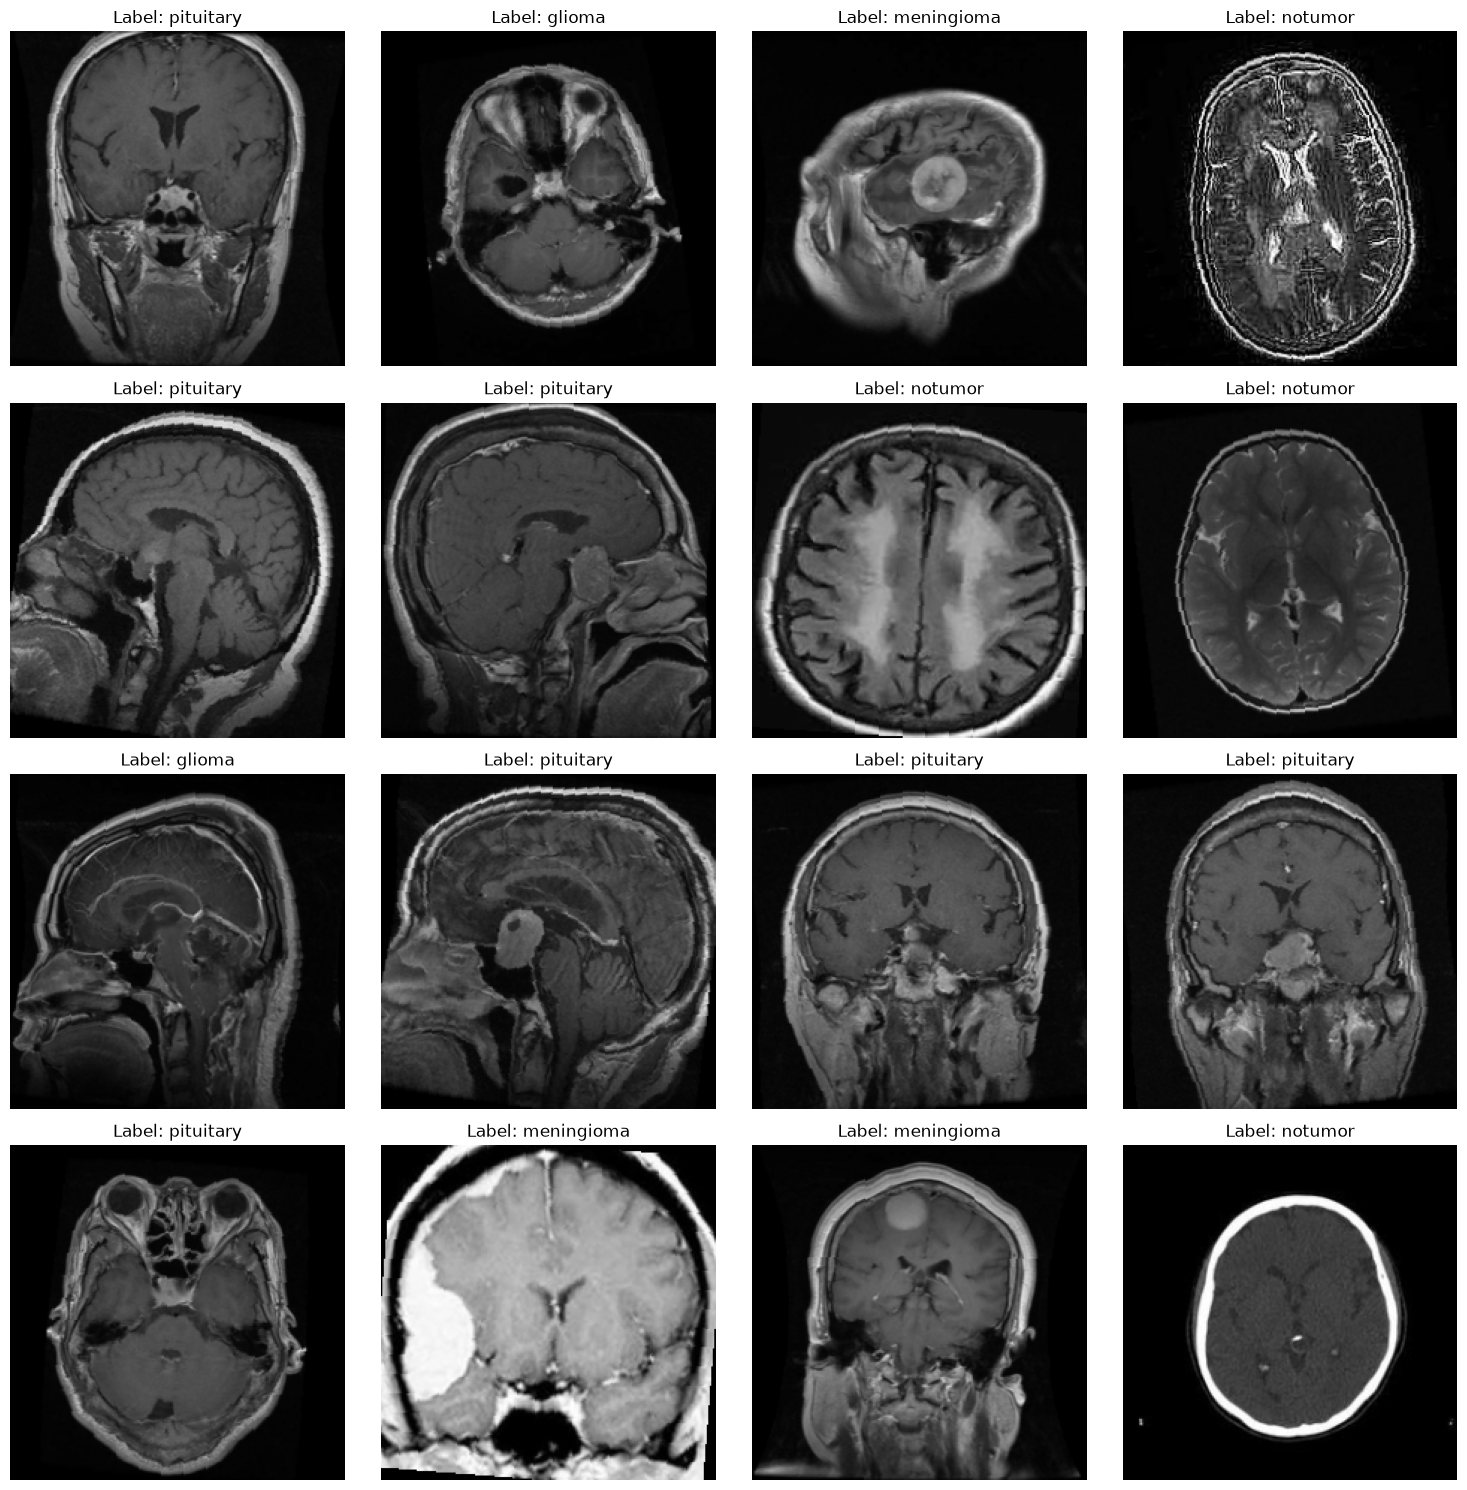

In [6]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

mean = np.array([0.1855, 0.1855, 0.1855])
std = np.array([0.1813, 0.1813, 0.1813])
images = (images.numpy().transpose((0, 2, 3, 1)) * std + mean).clip(0, 1)

num_images = len(images)
rows = int(np.ceil(num_images / 4))
fig, axes = plt.subplots(rows, 4, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(images[i])
        ax.set_title(f'Label: {train_dataset.classes[labels[i]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
class TumourClassifier(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super(TumourClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU(inplace=True)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.relu3 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=0.5) 
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

model = TumourClassifier(num_classes=4)
model.to(device)

TumourClassifier(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU(inplace=True)
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU(inplace=True)
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (relu3): ReLU(inplace=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Starting learning rate

# Initialize lists to store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 20
best_val_accuracy = 0.0
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.1)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2%}, '
          f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2%}')
    
    # Adjust learning rate based on validation loss
    lr_scheduler.step(val_loss)
    
    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'tumour_model.pth')

Epoch [1/20], Training Loss: 255.9400, Training Accuracy: 75.72%, Validation Loss: 0.4433, Validation Accuracy: 83.52%
Epoch [2/20], Training Loss: 120.2207, Training Accuracy: 87.24%, Validation Loss: 0.3460, Validation Accuracy: 87.64%
Epoch [3/20], Training Loss: 89.3058, Training Accuracy: 90.63%, Validation Loss: 0.2983, Validation Accuracy: 88.18%
Epoch [4/20], Training Loss: 69.2436, Training Accuracy: 93.03%, Validation Loss: 0.2665, Validation Accuracy: 89.86%
Epoch [5/20], Training Loss: 60.8743, Training Accuracy: 93.94%, Validation Loss: 0.2302, Validation Accuracy: 92.22%
Epoch [6/20], Training Loss: 47.9408, Training Accuracy: 95.43%, Validation Loss: 0.1967, Validation Accuracy: 92.98%
Epoch [7/20], Training Loss: 41.9561, Training Accuracy: 96.25%, Validation Loss: 0.2318, Validation Accuracy: 92.14%


In [ ]:
accuracy = correct / total
print(f'Validation Accuracy: {accuracy:.2%}')

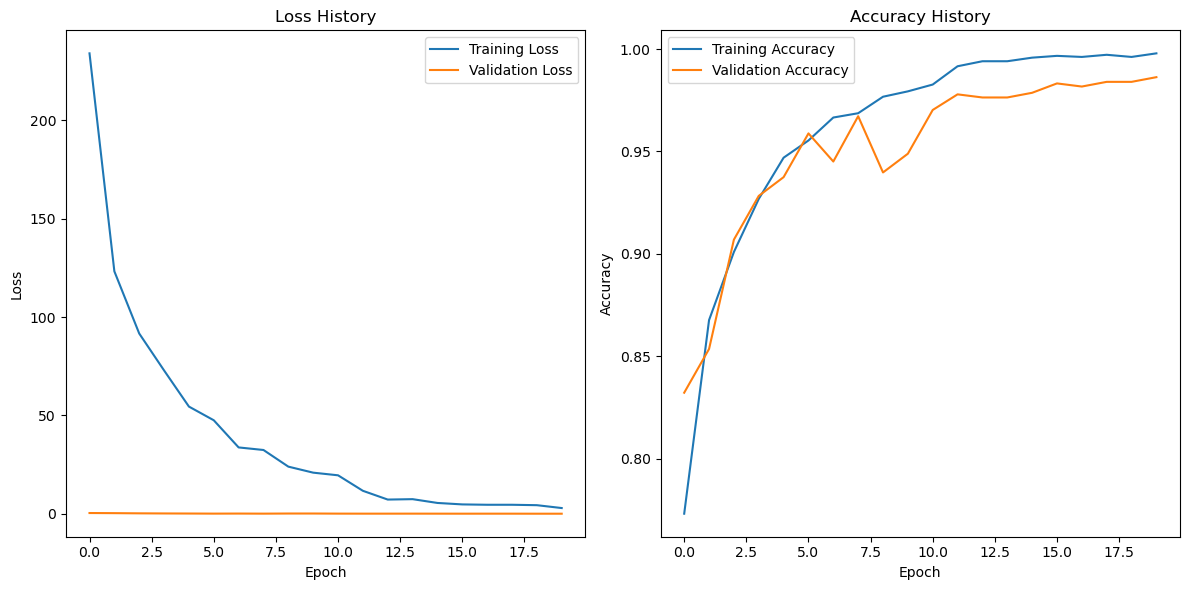

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()



In [10]:
Tumour_model = TumourClassifier(num_classes=4)
Tumour_model.load_state_dict(torch.load('tumour_model.pth'))
Tumour_model.to(device)

TumourClassifier(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU(inplace=True)
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU(inplace=True)
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (relu3): ReLU(inplace=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

In [25]:
test_dataset = ImageFolder('/Users/molly1/Desktop/year 3/Project David Jenkins/project/archive/Testing', transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Tumour_model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = Tumour_model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_accuracy = correct / total

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2%}')

Test Loss: 0.0795, Test Accuracy: 98.63%


              precision    recall  f1-score   support

      Glioma       0.99      0.97      0.98       300
  Meningioma       0.97      0.98      0.97       306
    Notumour       0.99      1.00      0.99       405
   Pituitary       1.00      0.99      1.00       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



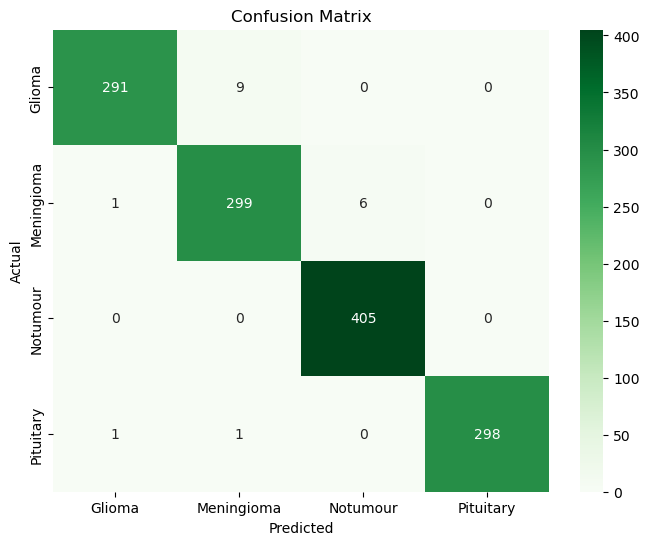

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sn
import pandas as pd

Tumour_model.eval()
y_true = []
y_predicted = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = Tumour_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_predicted.extend(predicted.cpu().numpy())

class_names = ['Glioma', 'Meningioma', 'Notumour', 'Pituitary']        
target_names = [str(class_name) for class_name in class_names]
print(classification_report(y_true, y_predicted, target_names=target_names))

conf_matrix = confusion_matrix(y_true, y_predicted)

plt.figure(figsize = (8,6))
sn.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
from sklearn.metrics import accuracy_score

#(TP)=true positive, (FP)=false positive, (FN)=false negative, (TN)=true negative
tp = np.diag(conf_matrix)
fp = np.sum(conf_matrix, axis=0) - tp
fn = np.sum(conf_matrix, axis=1) - tp
tn = np.sum(conf_matrix) - (tp + fp + fn)

accuracy_per_class = (tp+tn) / (tp + fp + fn + tn)
precision_per_class = tp / (tp + fp)
recall_per_class = tp / (tp + fn)
specificity_per_class = tn / (tn + fp)
f1_score_per_class = 2 * (precision_per_class * recall_per_class) / (precision_per_class + recall_per_class)

print(f"Accuracy: {accuracy_per_class}")
print(f"Precision: {precision_per_class}")
print(f"Recall: {recall_per_class}")
print(f"Specificity: {specificity_per_class}")     
print(f"F1-Score: {f1_score_per_class}")


Accuracy: [0.99160946 0.9870328  0.99542334 0.99847445]
Precision: [0.99317406 0.96763754 0.98540146 1.        ]
Recall: [0.97       0.97712418 1.         0.99333333]
Specificity: [0.99802176 0.99004975 0.99337748 1.        ]
F1-Score: [0.98145025 0.97235772 0.99264706 0.99665552]
